In [19]:
# Cell 1 — Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import (
    classification_report, confusion_matrix,
    f1_score, accuracy_score, precision_score, recall_score
)
import joblib
import os

print("✅ Libraries imported")

✅ Libraries imported


In [20]:
# Cell 2 — Load cleaned data from Week 1
train_df = pd.read_csv('../data/processed/train_cleaned.csv')
val_df   = pd.read_csv('../data/processed/val_cleaned.csv')
test_df  = pd.read_csv('../data/processed/test_cleaned.csv')

# Safety check: drop any rows where clean_text became empty/NaN after cleaning
for name, df in [('train', train_df), ('val', val_df), ('test', test_df)]:
    before = len(df)
    df.dropna(subset=['clean_text'], inplace=True)
    df['clean_text'] = df['clean_text'].astype(str)
    after = len(df)
    print(f"{name}: {before} -> {after} rows")

print("\n✅ Cleaned data reloaded")
print(f"Train: {len(train_df)} | Val: {len(val_df)} | Test: {len(test_df)}")

train: 10240 -> 10240 rows
val: 1284 -> 1284 rows
test: 1267 -> 1267 rows

✅ Cleaned data reloaded
Train: 10240 | Val: 1284 | Test: 1267


In [21]:
# Cell 3 — TF-IDF Vectorisation
tfidf = TfidfVectorizer(
    max_features=5000,      # cap vocabulary size — standard for short political statements
    ngram_range=(1, 2),     # unigrams + bigrams (captures phrases like "not true")
    min_df=2,               # ignore terms appearing in <2 documents
    max_df=0.9               # ignore overly common terms
)

X_train = tfidf.fit_transform(train_df['clean_text'])
X_val   = tfidf.transform(val_df['clean_text'])
X_test  = tfidf.transform(test_df['clean_text'])

y_train = train_df['binary_label']
y_val   = val_df['binary_label']
y_test  = test_df['binary_label']

print(f"✅ TF-IDF complete")
print(f"  Vocabulary size : {len(tfidf.vocabulary_)}")
print(f"  X_train shape   : {X_train.shape}")
print(f"  X_val shape     : {X_val.shape}")
print(f"  X_test shape    : {X_test.shape}")

# Save vectoriser for later use (DistilBERT comparison, Streamlit demo)
os.makedirs('D:/Project/Fake News Detection/models', exist_ok=True)
joblib.dump(tfidf, 'D:/Project/Fake News Detection/models/tfidf_vectorizer.pkl')
print("✅ Vectoriser saved to models/tfidf_vectorizer.pkl")

✅ TF-IDF complete
  Vocabulary size : 5000
  X_train shape   : (10240, 5000)
  X_val shape     : (1284, 5000)
  X_test shape    : (1267, 5000)
✅ Vectoriser saved to models/tfidf_vectorizer.pkl


In [22]:
# Cell 4 — Train all three models
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Linear SVM': LinearSVC(random_state=42, max_iter=2000),
    'Naive Bayes': MultinomialNB()
}

trained_models = {}

for name, model in models.items():
    print(f"Training {name}...")
    model.fit(X_train, y_train)
    trained_models[name] = model
    print(f"  ✅ {name} trained")

print("\n🎉 All 3 baseline models trained")

Training Logistic Regression...
  ✅ Logistic Regression trained
Training Linear SVM...
  ✅ Linear SVM trained
Training Naive Bayes...
  ✅ Naive Bayes trained

🎉 All 3 baseline models trained


In [23]:
# Cell 5 — Save trained models
for name, model in trained_models.items():
    filename = name.lower().replace(' ', '_')
    joblib.dump(model, f'D:/Project/Fake News Detection/models/{filename}.pkl')

print("✅ Models saved to models folder:")
print("  - logistic_regression.pkl")
print("  - linear_svm.pkl")
print("  - naive_bayes.pkl")

✅ Models saved to models folder:
  - logistic_regression.pkl
  - linear_svm.pkl
  - naive_bayes.pkl


In [24]:
# Cell 6 — Evaluation function
def evaluate_model(name, model, X, y_true, set_name="Validation"):
    y_pred = model.predict(X)
    acc = accuracy_score(y_true, y_pred)
    f1_macro = f1_score(y_true, y_pred, average='macro')
    prec = precision_score(y_true, y_pred, average='macro')
    rec = recall_score(y_true, y_pred, average='macro')

    print(f"\n{'='*50}")
    print(f"  {name}  —  {set_name} Set")
    print(f"{'='*50}")
    print(f"  Accuracy        : {acc:.4f}")
    print(f"  Macro F1        : {f1_macro:.4f}")
    print(f"  Macro Precision : {prec:.4f}")
    print(f"  Macro Recall    : {rec:.4f}")
    print(f"\n  Classification Report:")
    print(classification_report(y_true, y_pred, target_names=['Fake', 'Real']))

    return {'model': name, 'accuracy': acc, 'f1_macro': f1_macro,
            'precision_macro': prec, 'recall_macro': rec}

val_results = []
for name, model in trained_models.items():
    result = evaluate_model(name, model, X_val, y_val, "Validation")
    val_results.append(result)


  Logistic Regression  —  Validation Set
  Accuracy        : 0.6168
  Macro F1        : 0.6063
  Macro Precision : 0.6210
  Macro Recall    : 0.6112

  Classification Report:
              precision    recall  f1-score   support

        Fake       0.64      0.47      0.54       616
        Real       0.61      0.75      0.67       668

    accuracy                           0.62      1284
   macro avg       0.62      0.61      0.61      1284
weighted avg       0.62      0.62      0.61      1284


  Linear SVM  —  Validation Set
  Accuracy        : 0.6044
  Macro F1        : 0.6014
  Macro Precision : 0.6035
  Macro Recall    : 0.6019

  Classification Report:
              precision    recall  f1-score   support

        Fake       0.60      0.54      0.57       616
        Real       0.61      0.66      0.64       668

    accuracy                           0.60      1284
   macro avg       0.60      0.60      0.60      1284
weighted avg       0.60      0.60      0.60      1284


  

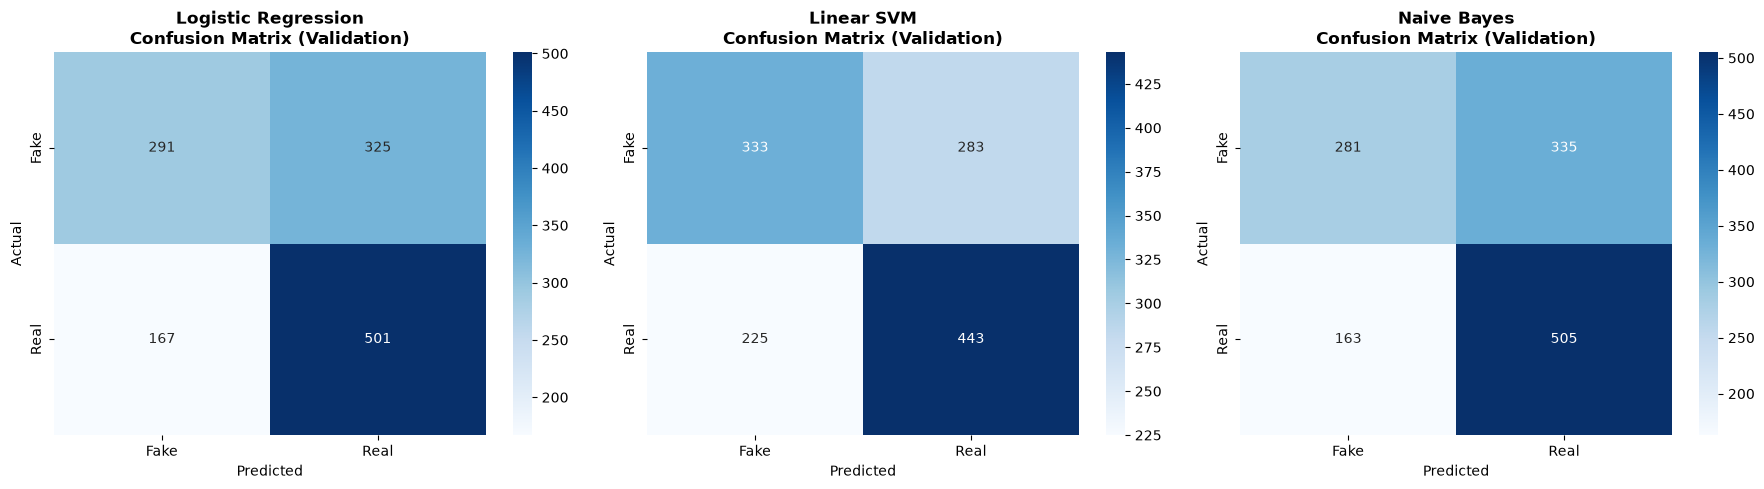

✅ Confusion matrices saved to results/baseline_confusion_matrices.png


In [25]:
# Cell 7 — Confusion matrices
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for idx, (name, model) in enumerate(trained_models.items()):
    y_pred = model.predict(X_val)
    cm = confusion_matrix(y_val, y_pred)

    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[idx],
                xticklabels=['Fake', 'Real'], yticklabels=['Fake', 'Real'])
    axes[idx].set_title(f'{name}\nConfusion Matrix (Validation)', fontweight='bold')
    axes[idx].set_xlabel('Predicted')
    axes[idx].set_ylabel('Actual')

plt.tight_layout()
plt.savefig('D:/Project/Fake News Detection/results/baseline_confusion_matrices.png', dpi=150)
plt.show()
print("✅ Confusion matrices saved to results/baseline_confusion_matrices.png")

=== Model Comparison (Validation Set) ===
              model  accuracy  f1_macro  precision_macro  recall_macro
Logistic Regression  0.616822  0.606291         0.620954      0.611201
         Linear SVM  0.604361  0.601436         0.603484      0.601879
        Naive Bayes  0.612150  0.599975         0.617037      0.606078


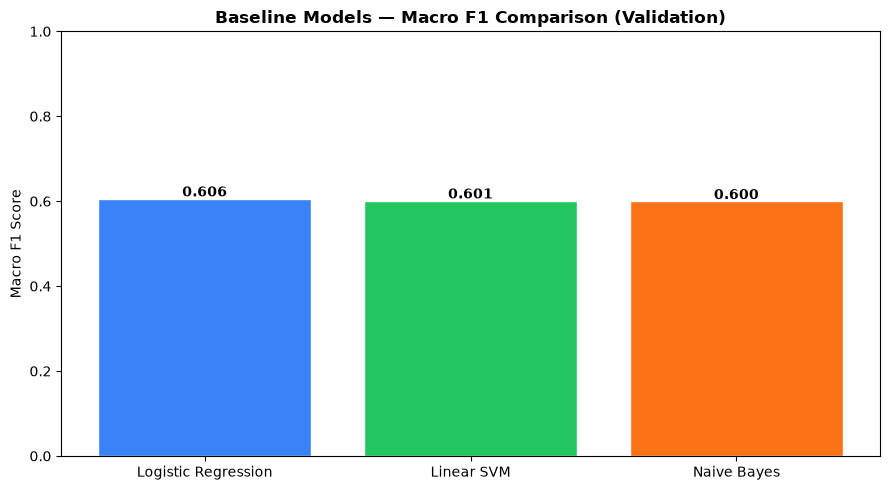


✅ Results saved to results/baseline_validation_results.csv


In [26]:
# Cell 8 — Compare all 3 models on Macro F1
results_df = pd.DataFrame(val_results)
results_df = results_df.sort_values('f1_macro', ascending=False)

print("=== Model Comparison (Validation Set) ===")
print(results_df.to_string(index=False))

plt.figure(figsize=(9, 5))
bars = plt.bar(results_df['model'], results_df['f1_macro'],
                color=['#3B82F6', '#22C55E', '#F97316'], edgecolor='white')
for bar, val in zip(bars, results_df['f1_macro']):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
              f'{val:.3f}', ha='center', fontweight='bold')
plt.title('Baseline Models — Macro F1 Comparison (Validation)', fontweight='bold')
plt.ylabel('Macro F1 Score')
plt.ylim(0, 1)
plt.tight_layout()
plt.savefig('../results/baseline_f1_comparison.png', dpi=150)
plt.show()

results_df.to_csv('D:/Project/Fake News Detection/results/baseline_validation_results.csv', index=False)
print("\n✅ Results saved to results/baseline_validation_results.csv")

In [27]:
# Cell 9 — Run best model on held-out test set
best_model_name = results_df.iloc[0]['model']
best_model = trained_models[best_model_name]

print(f"🏆 Best baseline model: {best_model_name}")
test_result = evaluate_model(best_model_name, best_model, X_test, y_test, "TEST")

# Save this as your RQ1 baseline answer (to compare against DistilBERT later)
import json
with open('D:/Project/Fake News Detection/results/baseline_best_model_test_result.json', 'w') as f:
    json.dump(test_result, f, indent=2)
print("✅ Saved baseline test result for later DistilBERT comparison")

🏆 Best baseline model: Logistic Regression

  Logistic Regression  —  TEST Set
  Accuracy        : 0.6180
  Macro F1        : 0.5973
  Macro Precision : 0.6089
  Macro Recall    : 0.5989

  Classification Report:
              precision    recall  f1-score   support

        Fake       0.58      0.45      0.51       553
        Real       0.64      0.75      0.69       714

    accuracy                           0.62      1267
   macro avg       0.61      0.60      0.60      1267
weighted avg       0.61      0.62      0.61      1267

✅ Saved baseline test result for later DistilBERT comparison
